# Exploración inicial

## Exploración del Dataset Original

In [8]:
# Vamos a cargar el dataset
# Previamente convertimos 1702 archivos originales en este dataset
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv(r"C:\Users\orlan\OneDrive\Documents\Tecnicatura\2A1C - Aprendizaje Automatico\Estacion Astronomica RG - Lidar GW\data\temperaturas_unificadas.csv", 
                 encoding= "ISO-8859-1")


In [5]:
print("Dimensiones del dataset original: ",df.shape)

Dimensiones del dataset original:  (40747, 1603)


In [9]:
df.head()

,archivo,fecha,time,68,168,268,368,468,568,668,...,159068,159168,159268,159368,159468,159568,159668,159768,159868,159968
0,20171124-0102_T60Z900,2017-11-24,8179000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,20171124-0102_T60Z900,2017-11-24,9079000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,20171124-0102_T60Z900,2017-11-24,9979000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,20171124-0102_T60Z900,2017-11-24,10879000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,20171124-0102_T60Z900,2017-11-24,11779000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Primera fecha: 2017-11-24 00:00:00
Última fecha: 2025-09-23 00:00:00

Mediciones por año
fecha
2017     119
2018    7354
2019    6154
2020    7930
2021     759
2022    4252
2023    5899
2024    6473
2025    1807
dtype: int64

Noches por año
fecha
2017     13
2018    225
2019    201
2020    244
2021     49
2022    200
2023    236
2024    256
2025     79
Name: fecha, dtype: int64


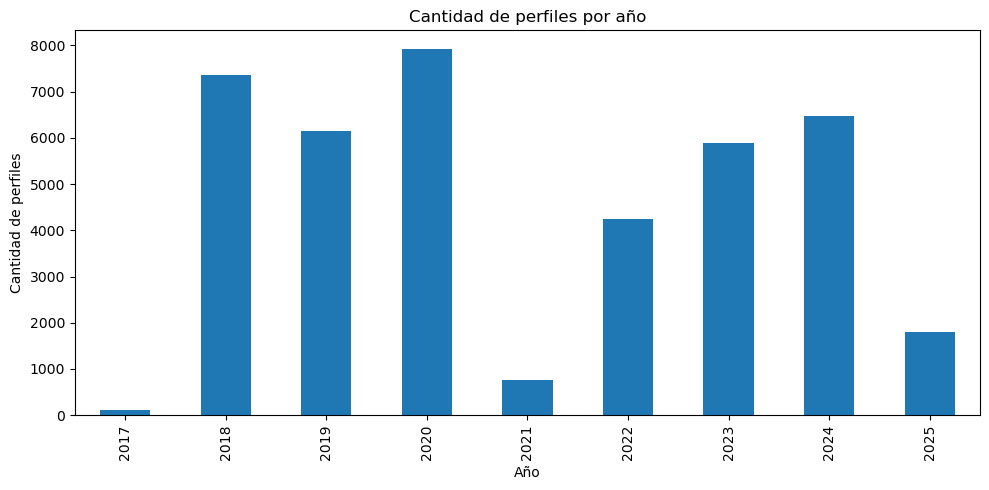

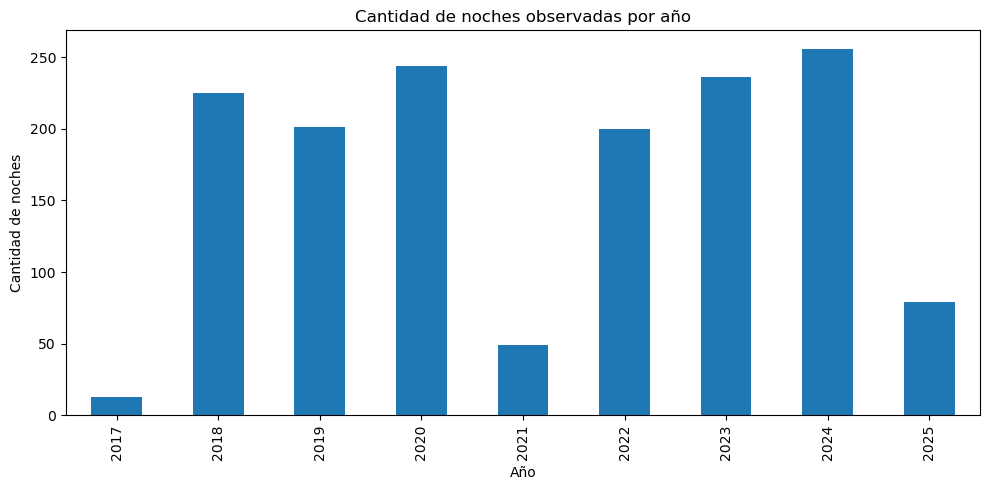

In [15]:
# Cobertura Temporal
# Vamos a relevar las fechas iniciales y finales disponibles en el dataset
# Vamos a ver cuántas mediciones por año tenemos
# Vamos a mostrar un gráfico

df["fecha"] = pd.to_datetime(df["fecha"])

print("Primera fecha:", df["fecha"].min())
print("Última fecha:", df["fecha"].max())

mediciones_anio = (df.groupby(df["fecha"].dt.year).size().sort_index())

print()
print("Mediciones por año")
print(mediciones_anio)

noches_anio = (df.groupby(df["fecha"].dt.year)["fecha"].nunique())

print()
print("Noches por año")
print(noches_anio)

plt.figure(figsize=(10,5))

mediciones_anio.plot(kind="bar")

plt.ylabel("Cantidad de perfiles")
plt.xlabel("Año")
plt.title("Cantidad de perfiles por año")

plt.tight_layout()
plt.show()

plt.figure(figsize=(10,5))

noches_anio.plot(kind="bar")

plt.ylabel("Cantidad de noches")
plt.xlabel("Año")
plt.title("Cantidad de noches observadas por año")

plt.tight_layout()
plt.show()

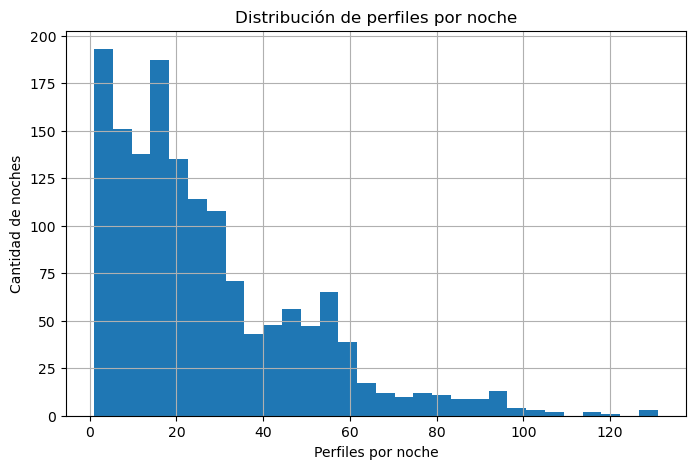

In [16]:
# Vamos a relevar cantidad de perfiles por noche y graficar

perfiles_noche = (df.groupby("fecha").size())

perfiles_noche.describe()
plt.figure(figsize=(8,5))

plt.hist(perfiles_noche,bins=30)

plt.xlabel("Perfiles por noche")
plt.ylabel("Cantidad de noches")

plt.title("Distribución de perfiles por noche")

plt.grid(True)

plt.show()


In [17]:
# Estamos cuidando la cantidad de memoria
# Ante reiterados inconvenientes, estamos tratando de evitar saturar la memoria

df.info(memory_usage="deep")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40747 entries, 0 to 40746
Columns: 1603 entries, archivo to 159968
dtypes: datetime64[ns](1), float64(1600), int64(1), object(1)
memory usage: 500.7 MB


Altura mínima con datos: 8068.0
Altura máxima con datos: 98868.0
Cantidad de niveles: 909


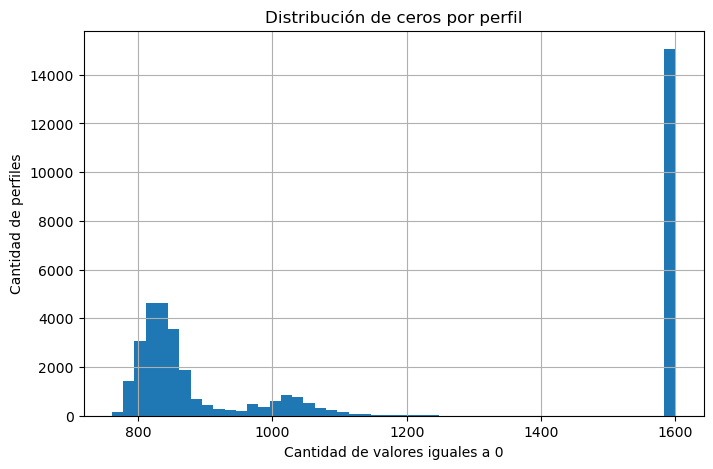

In [22]:
# Al ver el head del dataset vemos que hay bastantes ceros al principio
# Vamos a ver cuántos ceros hay en función de los primeros y últimos valores distintos de ceros.
# Vamos a ver cuántos ceros hay por perfil

temp_cols = df.columns[3:]

# convertir nombres de columnas a altura numérica
alturas = pd.Index(temp_cols).astype(float)

# identificar alturas que tienen al menos un valor distinto de cero
alturas_utiles = []

for col in temp_cols:
    if (df[col] != 0).any():
        alturas_utiles.append(float(col))

print("Altura mínima con datos:", min(alturas_utiles))
print("Altura máxima con datos:", max(alturas_utiles))
print("Cantidad de niveles:", len(alturas_utiles))

ceros_por_perfil = (df[temp_cols].eq(0).sum(axis=1))

plt.figure(figsize=(8,5))

plt.hist(ceros_por_perfil,bins=50)

plt.xlabel("Cantidad de valores iguales a 0")
plt.ylabel("Cantidad de perfiles")

plt.title("Distribución de ceros por perfil")

plt.grid(True)

plt.show()


### Notamos algo irregular al ver muchos perfiles con ~1600 ceros

In [23]:
# Vamos a identificar los perfiles con todo cero

mask_ceros = (
    df[temp_cols]
    .eq(0)
    .all(axis=1)
)

mask_ceros.sum()


np.int64(15055)

In [24]:
# Hay 15055 filas de ceros.

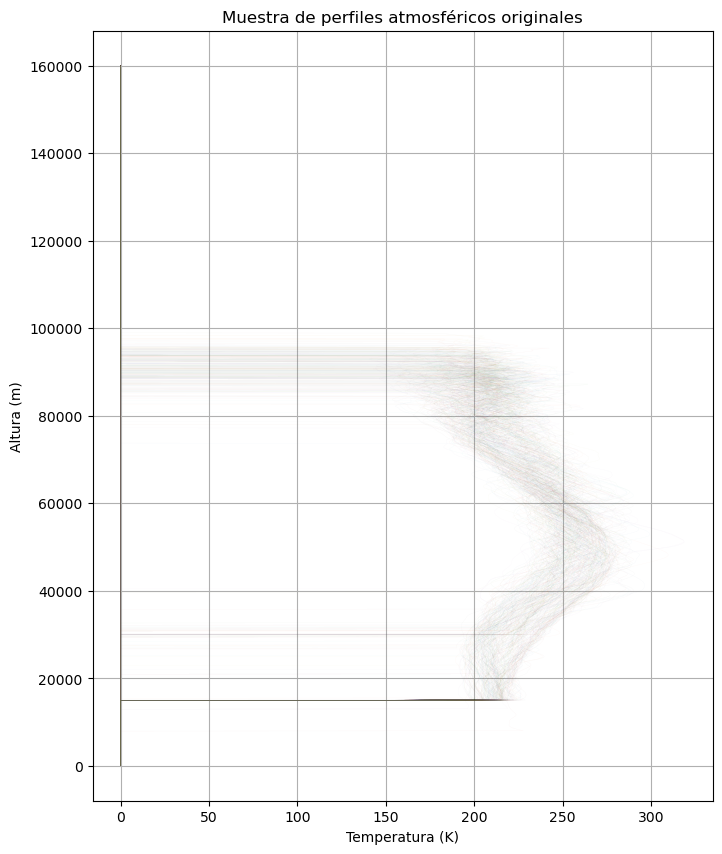

In [26]:
# Vamos a graficar un subconjunto de perfiles
# Mostrar la nube completa satura la memoria

# columnas de temperatura
temp_cols = df.columns[3:]

# alturas
alturas = temp_cols.astype(float)

# muestra aleatoria de perfiles
muestra = df.sample(
    n=500,
    random_state=42
)

plt.figure(figsize=(8,10))

for _, fila in muestra.iterrows():
    plt.plot(
        fila[temp_cols],
        alturas,
        alpha=0.03,
        linewidth=0.3
    )

plt.xlabel("Temperatura (K)")
plt.ylabel("Altura (m)")
plt.title("Muestra de perfiles atmosféricos originales")

plt.grid(True)

plt.show()

# Resumen de exploración inicial

Identificamos lo siguiente:
* El dataset original es de 40747 filas y 1603 columnas.
* Las fechas de los perfiles arrancan el 24/11/2017 y terminan el 23/09/2025.
* Sólo hay valores distintos de cero entre los 8068 y 98868 m.
* Hay 15055 filas vacias.
* Vemos que hay alguna forma de corte alrededor de las 15000 m.


